<a href="https://www.kaggle.com/code/naomiadeniji/netflix-content-strategy-analysis?scriptVersionId=295073277" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-shows/netflix_titles.csv


**Trends in Content Type, Geography, and Audience Targeting**

This analysis explores how Netflix’s content strategy has evolved over time using the Netflix Titles dataset.  
The goal is to uncover patterns in content type, geographic focus, audience targeting, genres, and content format that can inform strategic content investment decisions.


# **Dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#141414"
NETFLIX_DARK = "#1F1F1F"
NETFLIX_WHITE = "#F5F5F1"
NETFLIX_GRAY = "#B3B3B3"

def netflix_theme():
    plt.rcParams.update({
        "figure.facecolor": NETFLIX_BLACK,
        "axes.facecolor": NETFLIX_BLACK,
        "axes.edgecolor": NETFLIX_GRAY,
        "axes.labelcolor": NETFLIX_WHITE,
        "xtick.color": NETFLIX_WHITE,
        "ytick.color": NETFLIX_WHITE,
        "text.color": NETFLIX_WHITE,
        "axes.titleweight": "bold",
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "font.size": 12,
        "grid.color": NETFLIX_DARK,
        "grid.linestyle": "-",
        "grid.linewidth": 1,
        "axes.grid": True,
        "legend.frameon": False
    })

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(NETFLIX_DARK)
    ax.spines["bottom"].set_color(NETFLIX_DARK)
    ax.tick_params(axis="x", labelrotation=0)
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0.10)

netflix_theme()


df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.to_csv('cleaned_Netflix_Data.csv',index=False)

In [4]:
df.shape, df.columns

((8807, 12),
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
        'release_year', 'rating', 'duration', 'listed_in', 'description'],
       dtype='object'))

# **Dataset Cleaning**

In [5]:

for col in ["type", "title", "director", "cast", "country", "rating", "duration", "listed_in", "description"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()


df = df.replace({"nan": np.nan, "NaN": np.nan, "None": np.nan, "": np.nan})

# fill high-missing text fields with categories
df["director"] = df["director"].fillna("Unknown Director")
df["cast"] = df["cast"].fillna("Unknown Cast")
df["country"] = df["country"].fillna("Unknown Country")


In [6]:
# convert date_added 
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# create time features
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df[["date_added","year_added","month_added"]].head()


,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


** CHECK MISSING VALUES**

In [7]:
df.isnull().sum().sort_values(ascending=False).head(12)

month_added     98
date_added      98
year_added      98
rating           4
duration         3
show_id          0
country          0
cast             0
director         0
title            0
type             0
release_year     0
dtype: int64

# **Is Netflix shifting toward TV shows?**

TV shows can drive retention and long-term subscriptions more than one-time movie viewing.

In [8]:
type_over_time = (
    df.dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

type_over_time.tail()


type,Movie,TV Show
year_added,,
2017.0,839,325
2018.0,1237,388
2019.0,1424,575
2020.0,1284,594
2021.0,993,505


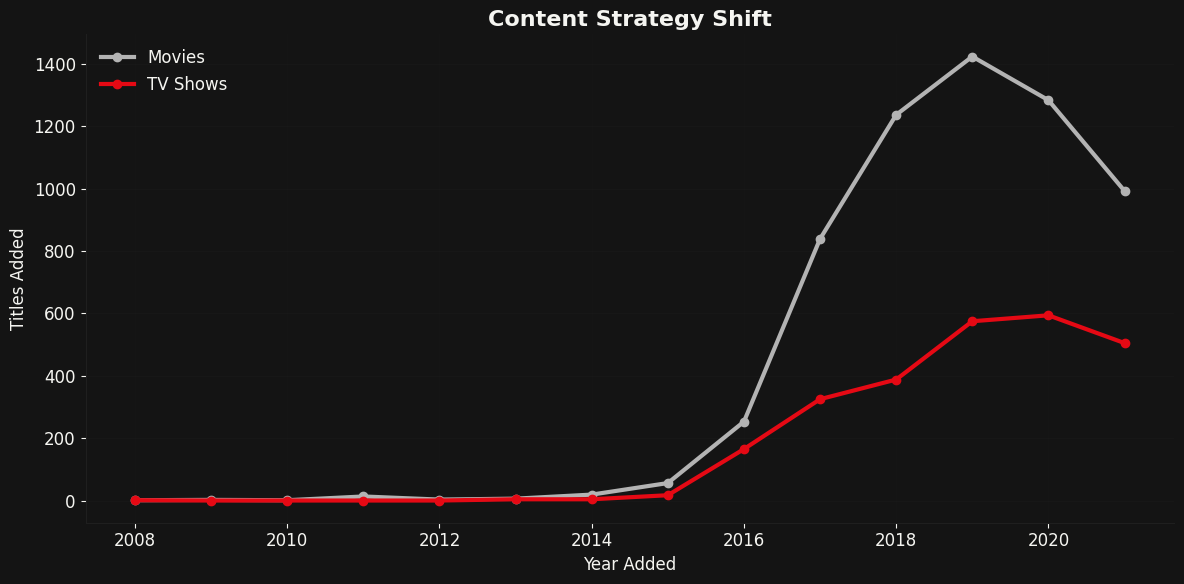

In [9]:
type_over_time = (
    df.dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12,6))

if "Movie" in type_over_time.columns:
    ax.plot(type_over_time.index, type_over_time["Movie"], marker="o", linewidth=3, label="Movies", color=NETFLIX_GRAY)
if "TV Show" in type_over_time.columns:
    ax.plot(type_over_time.index, type_over_time["TV Show"], marker="o", linewidth=3, label="TV Shows", color=NETFLIX_RED)

ax.set_title("Content Strategy Shift")
ax.set_xlabel("Year Added")
ax.set_ylabel("Titles Added")
clean_axes(ax)
ax.legend()

plt.tight_layout()
plt.show()
for label, color in [("Movie", NETFLIX_GRAY), ("TV Show", NETFLIX_RED)]:
    if label in type_over_time.columns and len(type_over_time.index) > 0:
        x = type_over_time.index[-1]
        y = type_over_time[label].iloc[-1]
        ax.text(x, y, f"  {label}: {int(y)}", va="center", color=color, fontweight="bold")



While movies continue to make up a larger share of Netflix’s catalog, the steady growth of TV shows over time indicates a strategic emphasis on episodic content. TV shows encourage longer user engagement and repeat viewing, which supports subscriber retention and reduces churn compared to one-time movie consumption.


# **Is Netflix becoming more adult-focused over time?**

In [10]:
top_ratings = df["rating"].value_counts().head(8).index
rating_year = (
    df[df["rating"].isin(top_ratings)]
    .dropna(subset=["year_added"])
    .groupby(["year_added","rating"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

rating_year.tail()


rating,PG,PG-13,R,TV-14,TV-MA,TV-PG,TV-Y,TV-Y7
year_added,,,,,,,,
2017.0,19,26,66,319,443,158,33,45
2018.0,33,53,129,448,642,179,37,43
2019.0,81,135,208,492,729,194,54,54
2020.0,86,122,188,438,671,146,102,55
2021.0,58,146,190,326,489,97,57,87


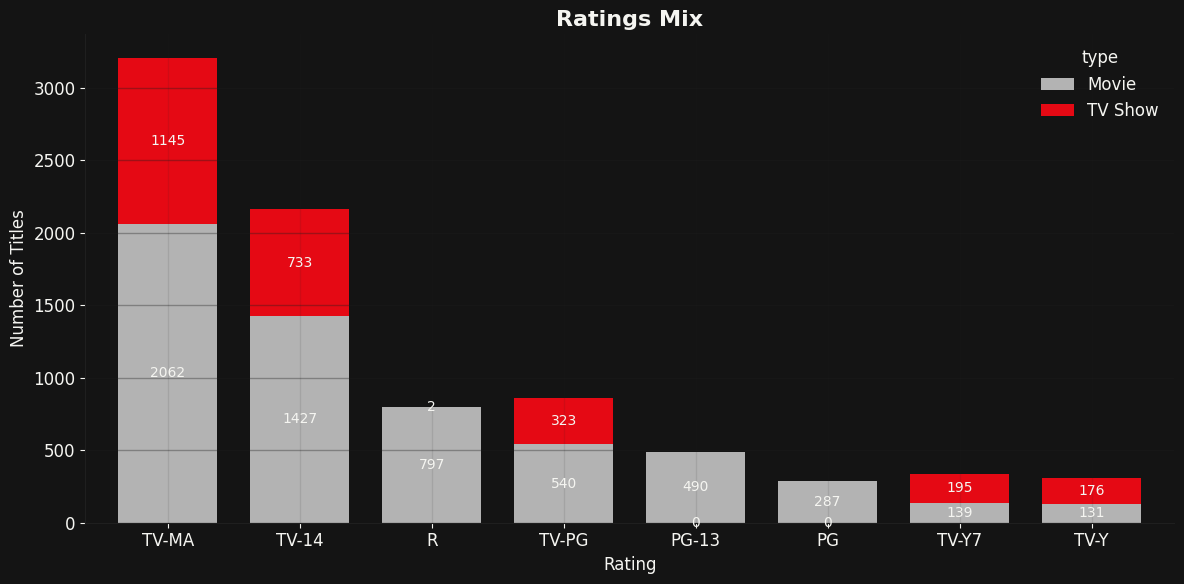

In [11]:
stacked_data = (
    df.groupby(["rating", "type"])
    .size()
    .unstack(fill_value=0)
)

top_ratings = stacked_data.sum(axis=1).sort_values(ascending=False).head(8).index
stacked_top = stacked_data.loc[top_ratings].sort_values(by=stacked_data.columns.tolist(), ascending=False)

fig, ax = plt.subplots(figsize=(12,6))

colors = []
for col in stacked_top.columns:
    colors.append(NETFLIX_RED if col == "TV Show" else NETFLIX_GRAY)

bars = stacked_top.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.75)

ax.set_title("Ratings Mix")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Titles")
clean_axes(ax)

for container in ax.containers:
    ax.bar_label(container, label_type="center", fontsize=10, color=NETFLIX_WHITE)

plt.tight_layout()
plt.show()


Mature ratings such as TV-MA and TV-14 dominate Netflix’s catalog and show consistent growth over time. This suggests that Netflix’s content strategy is heavily focused on adult audiences rather than family or children-focused programming. While this positioning supports binge-driven consumption, it may also limit appeal to younger or family-oriented households.


# **Which countries supply the most content and how has that changed?**

In [12]:
country_exploded = df.copy()
country_exploded["country_clean"] = country_exploded["country"].str.split(", ")
country_exploded = country_exploded.explode("country_clean")

top_countries = country_exploded["country_clean"].value_counts().head(10)
top_countries


country_clean
United States      3689
India              1046
Unknown Country     831
United Kingdom      804
Canada              445
France              393
Japan               318
Spain               232
South Korea         231
Germany             226
Name: count, dtype: int64

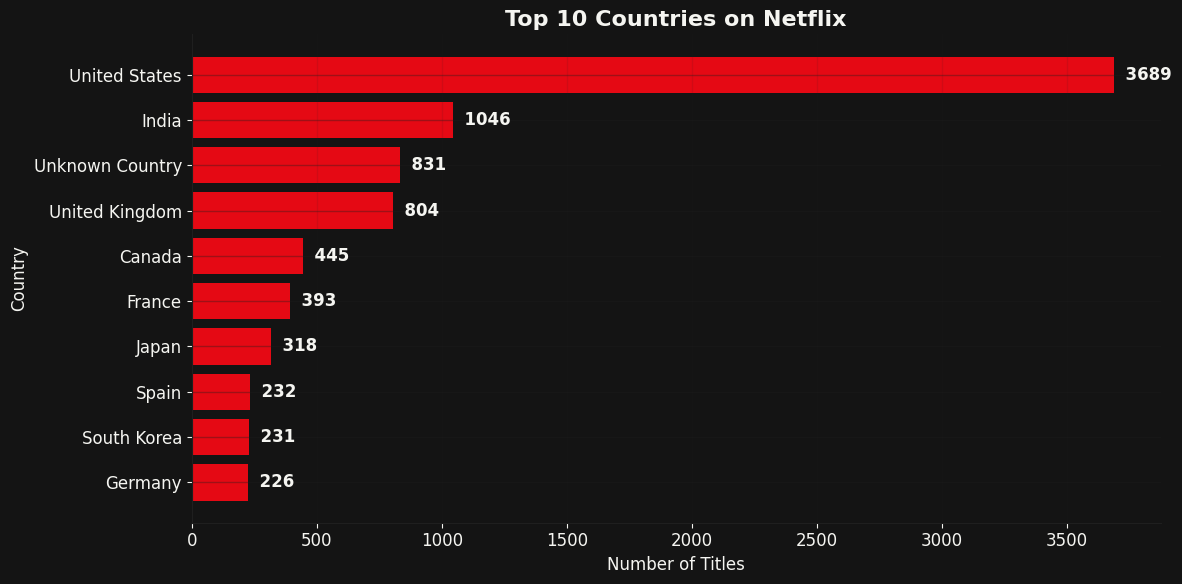

In [13]:
country_exploded = df.copy()
country_exploded["country_clean"] = country_exploded["country"].str.split(", ")
country_exploded = country_exploded.explode("country_clean")

top_countries = country_exploded["country_clean"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(12,6))
ax.barh(top_countries.index, top_countries.values, color=NETFLIX_RED)

ax.set_title("Top 10 Countries on Netflix")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Country")
clean_axes(ax)

for i, v in enumerate(top_countries.values):
    ax.text(v, i, f"  {int(v)}", va="center", color=NETFLIX_WHITE, fontweight="bold")

plt.tight_layout()
plt.show()


The United States remains the largest contributor to Netflix’s content library, followed by countries such as India and the United Kingdom. This distribution highlights Netflix’s dual strategy of maintaining strong US-based production while increasingly investing in international markets to support global subscriber growth and regional relevance.


# **What genres dominate Netflix and which are growing?**

In [14]:
genre_exploded = df.copy()
genre_exploded["genre"] = genre_exploded["listed_in"].str.split(", ")
genre_exploded = genre_exploded.explode("genre")

top_genres = genre_exploded["genre"].value_counts().head(10)
top_genres


genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

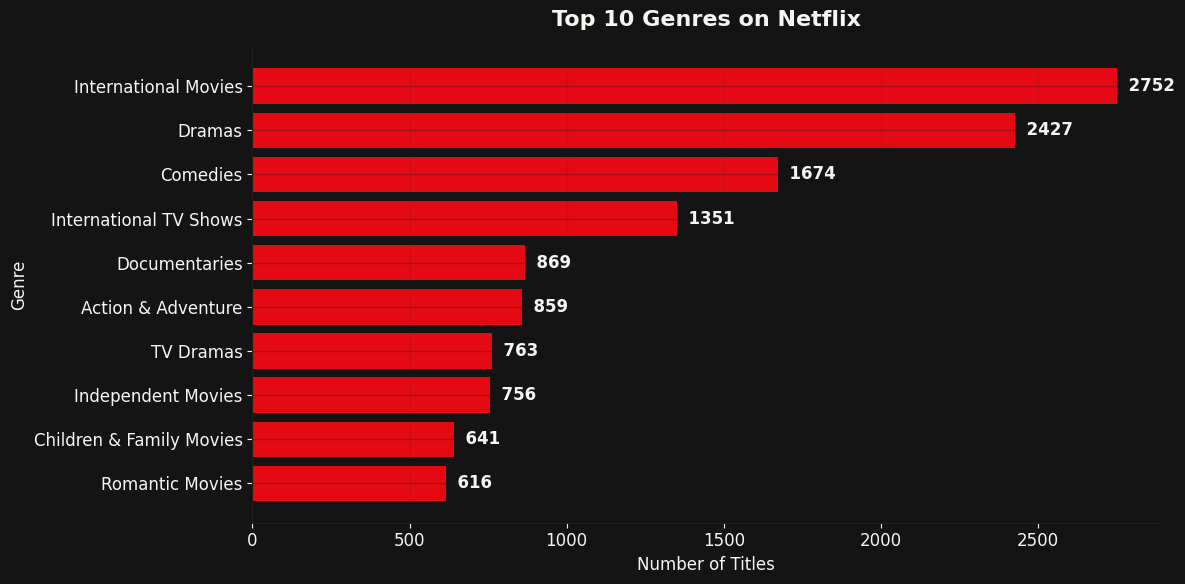

In [15]:
# explode genres
genre_exploded = df.copy()
genre_exploded["genre"] = genre_exploded["listed_in"].str.split(", ")
genre_exploded = genre_exploded.explode("genre")

top_genres = genre_exploded["genre"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(12,6))
ax.barh(top_genres.index, top_genres.values, color=NETFLIX_RED)

ax.set_title("Top 10 Genres on Netflix", pad=15)
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Genre")
clean_axes(ax)

# value labels
for i, v in enumerate(top_genres.values):
    ax.text(v, i, f"  {int(v)}", va="center", color=NETFLIX_WHITE, fontweight="bold")

plt.tight_layout()
plt.show()


Dramas and international content are the most prevalent genres on Netflix, indicating a strong focus on narrative-driven and globally appealing storytelling. The concentration of titles within a few dominant genres may signal content saturation, suggesting opportunities for Netflix to differentiate by investing in underrepresented or emerging genres.


# **Are movies getting longer or shorter over time?**

In [16]:
movies = df[df["type"] == "Movie"].copy()
movies = movies[movies["duration"].str.contains("min", na=False)]
movies["duration_min"] = movies["duration"].str.replace(" min", "", regex=False).astype(float)

avg_movie_duration = (
    movies.dropna(subset=["year_added"])
    .groupby("year_added")["duration_min"]
    .mean()
    .sort_index()
)

avg_movie_duration.tail()


year_added
2017.0     95.680191
2018.0    101.739693
2019.0     99.923455
2020.0    101.585670
2021.0    102.839879
Name: duration_min, dtype: float64

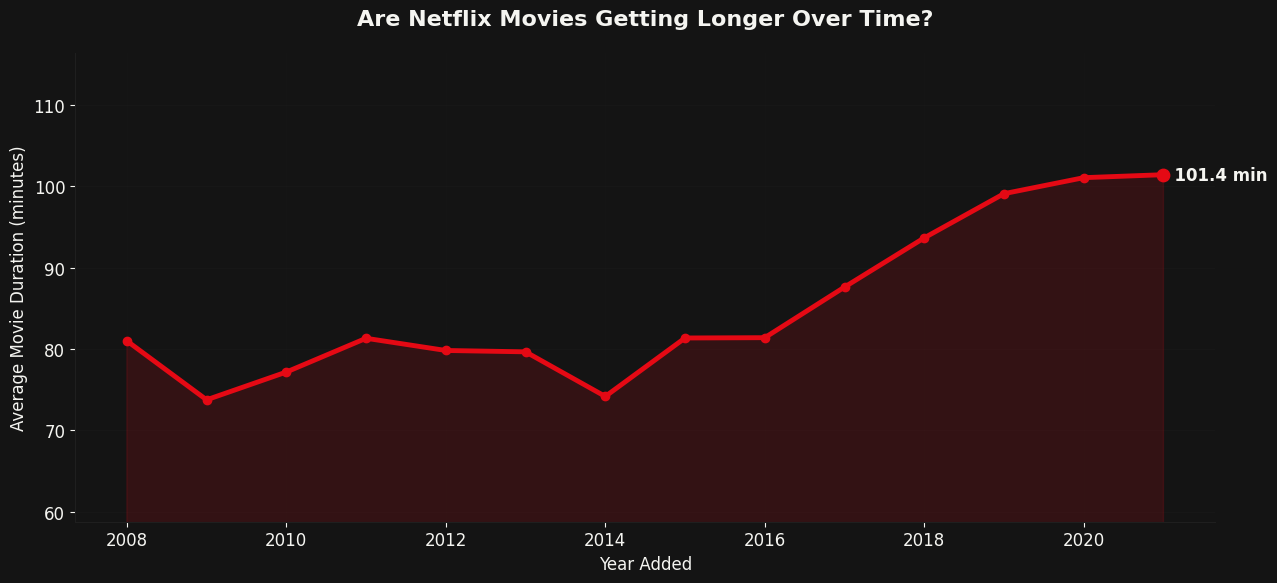

In [17]:
# --- Prep movie duration data (same logic, slightly cleaner) ---
movies = df[df["type"] == "Movie"].copy()
movies = movies[movies["duration"].str.contains("min", na=False)]

movies["duration_min"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(float)
)

avg_movie_duration = (
    movies
    .dropna(subset=["year_added"])
    .groupby("year_added")["duration_min"]
    .mean()
    .sort_index()
)

# Smooth it a bit so it tells a story
smooth_duration = avg_movie_duration.rolling(window=3, min_periods=1).mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=(13,6))

ax.plot(
    smooth_duration.index,
    smooth_duration.values,
    linewidth=3.5,
    color=NETFLIX_RED,
    marker="o",
    zorder=3
)

# Soft fill under the curve (very Netflix)
ax.fill_between(
    smooth_duration.index,
    smooth_duration.values,
    color=NETFLIX_RED,
    alpha=0.15,
    zorder=2
)

# Titles and labels
ax.set_title("Are Netflix Movies Getting Longer Over Time?", pad=20)
ax.set_xlabel("Year Added")
ax.set_ylabel("Average Movie Duration (minutes)")

# Add breathing room on y-axis
y_min = smooth_duration.min() - 15
y_max = smooth_duration.max() + 15
ax.set_ylim(y_min, y_max)

clean_axes(ax)

# Highlight latest value
last_year = smooth_duration.index[-1]
last_value = smooth_duration.values[-1]

ax.scatter(last_year, last_value, s=80, color=NETFLIX_RED, zorder=4)
ax.text(
    last_year,
    last_value,
    f"  {last_value:.1f} min",
    va="center",
    color=NETFLIX_WHITE,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


The average duration of movies on Netflix has remained relatively stable over time, with only slight increases in recent years. This suggests that Netflix has not significantly altered movie length as part of its content strategy, indicating stable audience preferences and a consistent approach to movie format design.


# **Key Insights and Business Implications**

1. Netflix experienced a rapid expansion in its content library between 2016 and 2019, indicating an aggressive growth phase aimed at global market penetration. The slowdown in new content additions after 2020 suggests a strategic shift toward optimizing content quality, managing production costs, and maximizing the value of existing titles.

2. While movies continue to dominate the overall catalog, the consistent growth of TV shows highlights Netflix’s focus on episodic content as a key driver of subscriber retention. TV shows encourage repeat viewing and long-term engagement, making them strategically valuable despite higher production complexity.

3. Netflix’s catalog is heavily skewed toward mature ratings such as TV-MA and TV-14, signaling a strong emphasis on adult audiences. This positioning supports binge-watching behavior and aligns with Netflix’s brand identity, but may limit appeal to family-oriented or younger demographics.

4. The United States remains the largest contributor to Netflix content; however, the increasing presence of titles from countries such as India and the United Kingdom reflects Netflix’s commitment to global expansion. Investing in regional content allows Netflix to better serve local audiences and compete with regional streaming platforms.

5. Drama and international genres dominate Netflix’s content mix, suggesting a preference for narrative-driven storytelling with broad global appeal. The concentration within a few genres may indicate saturation, presenting opportunities for Netflix to differentiate by investing in underrepresented genres.

6. Movie durations have remained relatively stable over time, implying that Netflix has not significantly altered film length as part of its content strategy. This consistency suggests stable audience preferences and a deliberate focus on predictable content formats rather than experimentation in runtime.
